# 15. Диагностика векторов атак в WildJailbreak

**Зачем:** прежде чем вкладываться в препроцессинг (NFKC, удаление homoglyph/zero-width, base64-декод, regex-признаки), надо измерить — **есть ли в данных вообще соответствующие векторы атак**. Если их доля ничтожна, эти методы не двинут ROC и тратить силы не стоит.

**Что меряем** (один проход по текстам, без обучения):
1. **Обфускация символами** — не-ASCII, homoglyph (кириллица/греческий в латинском тексте), zero-width / невидимые символы, эмодзи.
2. **Кодирование** — base64-подобные блоки, hex, leetspeak, ROT-подобные.
3. **Структурные паттерны джейлбрейка** — ролевые обёртки, инструкции переопределения, маркеры ('ignore previous', 'you are now', 'DAN', 'pretend', и т.п.).

**Как читать:** сравниваем долю каждого вектора в `adversarial_harmful` (атаки) против `adversarial_benign` (безопасные в том же стиле). Вектор полезен для детекции, только если он **чаще встречается в harmful, чем в benign** — иначе это маркер стиля, а не интента, и он лишь усилит ORR.

**Связь с задачей:** из nb13/eda известно, что safe и harmful в eval написаны в одном адверсариальном стиле и различаются только интентом. Если структурные паттерны встречаются в обоих классах одинаково — это подтверждает, что они кодируют стиль, и regex-признаки не помогут. Если же какой-то вектор асимметричен (чаще в harmful) — это кандидат на полезный признак.

In [1]:
import json
import re
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Переиспользуем данные из 01_eda, если ноутбук запущен в той же сессии;
# иначе грузим raw сами.
data_dir = Path('../data')

def load_jsonl(path):
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

try:
    train_df
    eval_df
    print('Переиспользую train_df/eval_df из текущей сессии')
except NameError:
    print('Загружаю raw заново')
    train_df = load_jsonl(data_dir / 'raw' / 'wildjailbreak_train.jsonl')
    eval_df = load_jsonl(data_dir / 'raw' / 'wildjailbreak_eval.jsonl')

# Текст для анализа: для eval — adversarial; для train — adversarial, иначе vanilla
def get_text(row):
    adv = row.get('adversarial', '')
    if isinstance(adv, str) and adv.strip():
        return adv
    return str(row.get('vanilla', ''))

print('train:', len(train_df), '| eval:', len(eval_df))

Загружаю raw заново
train: 261559 | eval: 2210


## 1. Детекторы векторов атак

Каждый детектор — функция text → bool. Намеренно простые и прозрачные.

In [2]:
# --- Обфускация символами ---
ZERO_WIDTH = ['\u200b', '\u200c', '\u200d', '\u2060', '\ufeff']
# Кириллические/греческие буквы, визуально похожие на латиницу
HOMOGLYPH_RANGES = [(0x0400, 0x04FF), (0x0370, 0x03FF)]  # Cyrillic, Greek

def has_non_ascii(t):
    return any(ord(c) > 127 for c in t)

def has_zero_width(t):
    return any(z in t for z in ZERO_WIDTH)

def has_homoglyph(t):
    # латиница присутствует И есть кириллица/греческий → вероятная подмена
    has_latin = any('a' <= c.lower() <= 'z' for c in t)
    has_confusable = any(any(lo <= ord(c) <= hi for lo, hi in HOMOGLYPH_RANGES) for c in t)
    return has_latin and has_confusable

def has_emoji(t):
    return any(0x1F000 <= ord(c) <= 0x1FAFF or 0x2600 <= ord(c) <= 0x27BF for c in t)

# --- Кодирование ---
BASE64_RE = re.compile(r'(?:[A-Za-z0-9+/]{20,}={0,2})')
HEX_RE = re.compile(r'(?:\\x[0-9a-fA-F]{2}){4,}|(?:0x[0-9a-fA-F]{6,})')

def has_base64(t):
    for m in BASE64_RE.findall(t):
        # отсев обычных длинных слов: base64 обычно имеет смесь регистра/цифр
        if any(ch.isdigit() for ch in m) and any(ch.isupper() for ch in m) and any(ch.islower() for ch in m):
            return True
    return False

def has_hex_encoding(t):
    return bool(HEX_RE.search(t))

def has_leetspeak(t):
    # грубо: слова со смесью букв и цифр-заменителей
    return bool(re.search(r'\b[a-zA-Z]*[0-9@$][a-zA-Z]*[0-9@$]?[a-zA-Z]+\b', t)) and \
           bool(re.search(r'[a-zA-Z][0-9@$][a-zA-Z]', t))

# --- Структурные паттерны джейлбрейка ---
JB_PATTERNS = {
    'role_play': r'\b(you are|act as|pretend|imagine you|roleplay|role.play|as an?|in the role)\b',
    'ignore_override': r'\b(ignore (all |the |your )?(previous|prior|above)|disregard|override|forget (your|the|all))\b',
    'jailbreak_names': r'\b(DAN|do anything now|jailbreak|developer mode|unfiltered|no restrictions?|without (any )?(limitations?|restrictions?|filters?))\b',
    'fictional_frame': r'\b(fictional|hypothetical|story|novel|screenplay|in a world|creative writing)\b',
    'authority_frame': r'\b(researcher|professor|expert|historian|journalist|doctor|scientist|for (a|my) (study|research|paper))\b',
    'compliance_push': r'\b(you must|you should|it is (essential|important|crucial)|don.t refuse|never say no)\b',
}
JB_COMPILED = {k: re.compile(v, re.IGNORECASE) for k, v in JB_PATTERNS.items()}

def structural_flags(t):
    return {k: bool(rx.search(t)) for k, rx in JB_COMPILED.items()}

DETECTORS = {
    'non_ascii': has_non_ascii,
    'zero_width': has_zero_width,
    'homoglyph': has_homoglyph,
    'emoji': has_emoji,
    'base64': has_base64,
    'hex_encoding': has_hex_encoding,
    'leetspeak': has_leetspeak,
}
print('Детекторов обфускации/кодирования:', len(DETECTORS))
print('Структурных паттернов:', len(JB_COMPILED))

Детекторов обфускации/кодирования: 7
Структурных паттернов: 6


## 2. Применяем ко всем 4 подтипам

Считаем долю каждого вектора по `data_type`. Ключевое сравнение — adversarial_harmful vs adversarial_benign.

In [3]:
# Анализируем train (там все 4 типа) + отдельно eval для сверки
def analyze(df, label):
    rows = []
    for _, r in df.iterrows():
        t = get_text(r)
        flags = {name: fn(t) for name, fn in DETECTORS.items()}
        flags.update(structural_flags(t))
        flags['data_type'] = r['data_type']
        flags['source'] = label
        rows.append(flags)
    return pd.DataFrame(rows)

# train может быть большим — берём подвыборку для скорости, сбалансированную по типам
SAMPLE_PER_TYPE = 5000  # на каждый data_type; поставь None для полного прохода
if SAMPLE_PER_TYPE:
    parts = []
    for dt, grp in train_df.groupby('data_type'):
        parts.append(grp.sample(min(SAMPLE_PER_TYPE, len(grp)), random_state=42))
    train_sample = pd.concat(parts)
else:
    train_sample = train_df

flags_train = analyze(train_sample, 'train')
flags_eval = analyze(eval_df, 'eval')
all_flags = pd.concat([flags_train, flags_eval], ignore_index=True)

feat_cols = list(DETECTORS.keys()) + list(JB_COMPILED.keys())
print('Проанализировано: train', len(flags_train), '| eval', len(flags_eval))

Проанализировано: train 20000 | eval 2210


In [4]:
# Доля каждого вектора по data_type (train sample)
prev = flags_train.groupby('data_type')[feat_cols].mean().T
prev = prev[['vanilla_benign', 'vanilla_harmful', 'adversarial_benign', 'adversarial_harmful']]
print('Доля примеров с вектором атаки, по data_type (train):')
print((prev * 100).round(1).to_string())

Доля примеров с вектором атаки, по data_type (train):
data_type        vanilla_benign  vanilla_harmful  adversarial_benign  adversarial_harmful
non_ascii                   0.7              0.8                 3.8                  4.7
zero_width                  0.0              0.0                 0.0                  0.0
homoglyph                   0.0              0.0                 0.0                  0.0
emoji                       0.0              0.0                 0.3                  0.5
base64                      0.0              0.0                 0.0                  0.0
hex_encoding                0.0              0.0                 0.0                  0.0
leetspeak                   0.0              0.0                 0.2                  0.1
role_play                   0.7              3.0                74.4                 72.1
ignore_override             0.0              0.1                 2.0                  4.1
jailbreak_names             0.0              0

## 3. Ключевой график: асимметрия harmful vs benign

Для каждого вектора — доля в adversarial_harmful против adversarial_benign. Вектор полезен для **детекции интента**, только если столбцы заметно различаются. Если равны — это маркер стиля (общий для обоих классов), он не поможет и лишь поднимет ORR.

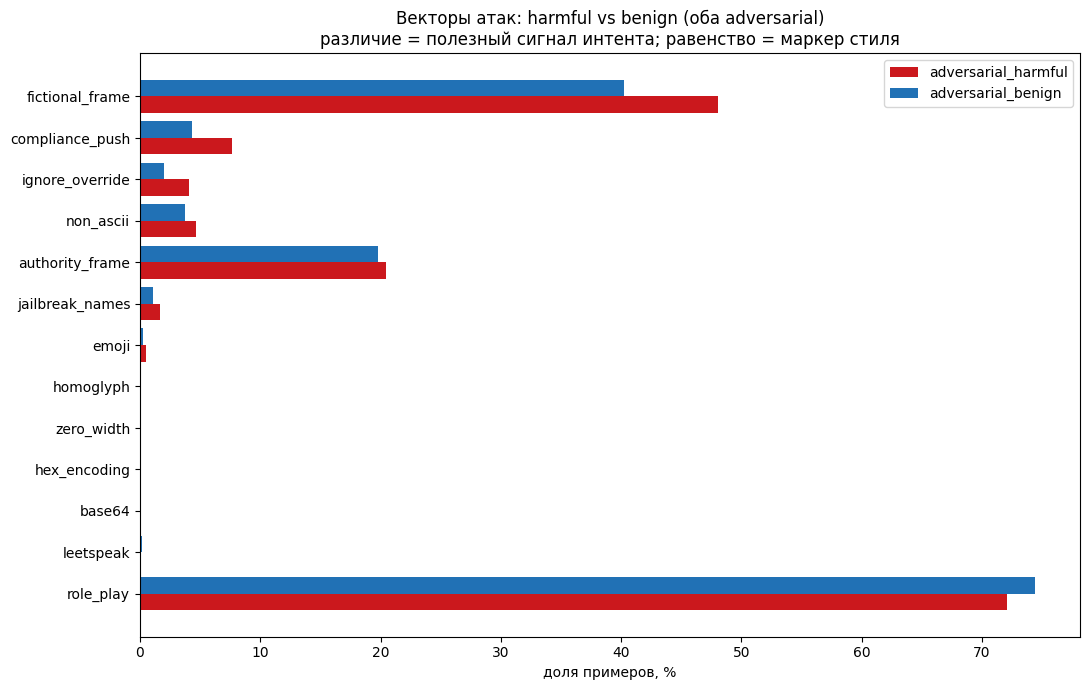


Асимметрия (harmful - benign), процентные пункты:
role_play         -2.3
leetspeak         -0.1
base64             0.0
hex_encoding       0.0
zero_width         0.0
homoglyph          0.0
emoji              0.2
jailbreak_names    0.6
authority_frame    0.7
non_ascii          0.9
ignore_override    2.1
compliance_push    3.3
fictional_frame    7.8


In [5]:
adv_h = prev['adversarial_harmful']
adv_b = prev['adversarial_benign']
diff = (adv_h - adv_b).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(diff))
ax.barh(y - 0.2, adv_h[diff.index]*100, 0.4, label='adversarial_harmful', color='#cb181d')
ax.barh(y + 0.2, adv_b[diff.index]*100, 0.4, label='adversarial_benign', color='#2171b5')
ax.set_yticks(y)
ax.set_yticklabels(diff.index)
ax.set_xlabel('доля примеров, %')
ax.set_title('Векторы атак: harmful vs benign (оба adversarial)\n'
             'различие = полезный сигнал интента; равенство = маркер стиля')
ax.legend()
plt.tight_layout()
plt.savefig('../results/diagnostics/nb15_attack_vectors.png', dpi=150, bbox_inches='tight') if Path('../results/diagnostics').exists() else None
plt.show()

print('\nАсимметрия (harmful - benign), процентные пункты:')
print((diff * 100).round(1).to_string())

## 4. Оценка полезности: насколько вектор разделяет классы

Для каждого вектора считаем простую меру информативности — разность долей и lift. Грубо оцениваем, сколько ROC мог бы дать один такой признак (через AUC одиночного бинарного признака на adversarial-подмножестве).

In [6]:
from sklearn.metrics import roc_auc_score

# adversarial-подмножество train
adv = flags_train[flags_train['data_type'].isin(['adversarial_harmful', 'adversarial_benign'])].copy()
adv['y'] = (adv['data_type'] == 'adversarial_harmful').astype(int)

rows = []
for f in feat_cols:
    ph = adv.loc[adv['y']==1, f].mean()
    pb = adv.loc[adv['y']==0, f].mean()
    # AUC одиночного бинарного признака
    try:
        auc = roc_auc_score(adv['y'], adv[f].astype(int))
    except Exception:
        auc = np.nan
    rows.append({'vector': f, 'in_harmful_%': ph*100, 'in_benign_%': pb*100,
                 'diff_pp': (ph-pb)*100, 'single_feat_auc': auc})

util = pd.DataFrame(rows).sort_values('single_feat_auc', ascending=False)
print('Информативность векторов на adversarial-подмножестве (train):')
print('(single_feat_auc=0.5 → бесполезен; >0.55 → есть сигнал)')
print(util.round(2).to_string(index=False))

if Path('../results/diagnostics').exists():
    util.to_csv('../results/diagnostics/nb15_vector_utility.csv', index=False)

Информативность векторов на adversarial-подмножестве (train):
(single_feat_auc=0.5 → бесполезен; >0.55 → есть сигнал)
         vector  in_harmful_%  in_benign_%  diff_pp  single_feat_auc
fictional_frame         48.04        40.22     7.82             0.54
compliance_push          7.64         4.30     3.34             0.52
ignore_override          4.06         2.00     2.06             0.51
      non_ascii          4.66         3.76     0.90             0.50
authority_frame         20.48        19.82     0.66             0.50
jailbreak_names          1.70         1.10     0.60             0.50
          emoji          0.50         0.28     0.22             0.50
     zero_width          0.04         0.02     0.02             0.50
      homoglyph          0.04         0.02     0.02             0.50
         base64          0.00         0.00     0.00             0.50
   hex_encoding          0.00         0.00     0.00             0.50
      leetspeak          0.06         0.18    -0.12   

## 5. Вывод

Числа из фактического прогона (train sample 20000, по 5000 на подтип).

### Символьная обфускация и кодирование — отсутствуют как класс

| Вектор | harmful | benign |
|--------|---------|--------|
| zero_width | 0.0% | 0.0% |
| homoglyph | 0.0% | 0.0% |
| base64 | 0.0% | 0.0% |
| hex_encoding | 0.0% | 0.0% |

Ровно ноль во всех подтипах. WildJailbreak не использует символьные трюки — атаки
чисто семантические (нарративные/ролевые обёртки). Следствие: **NFKC-нормализация,
удаление homoglyph/zero-width, base64-декодирование на этих данных не дадут ничего** —
обрабатывать нечего. Эти три препроцессинг-плана закрыты по отсутствию мишени.

### Структурные паттерны есть, но симметричны между классами

Лучший разделяющий признак — `fictional_frame`: 48.0% в harmful против 40.2% в benign,
`single_feat_auc = 0.54`. Остальные ближе к 0.50; `role_play` даже отрицательный
(74% benign против 72% harmful). То есть джейлбрейк-обёртки распределены между harmful
и benign почти поровну — это **маркеры стиля, общие для обоих классов, а не сигнал интента**.

Это прямое подтверждение конструкции датасета: adversarial_benign намеренно имитирует
стиль adversarial_harmful. Поэтому любой признак, ловящий стиль (regex по обёрткам),
срабатывает на обоих классах одинаково — поднимает ORR, не поднимая recall. Regex-план
по структурным паттернам бесперспективен: AUC 0.54 у лучшего признака, в ансамбле с
1024D-эмбеддингом (который стиль уже кодирует) это шум, не сдвиг ROC.

### Общий вывод

Из четырёх препроцессинг-идей живых нет:
- NFKC / homoglyph / zero-width / base64 — нет векторов в данных (0.0%);
- regex структурных паттернов — симметричны (AUC ≤ 0.54), кодируют стиль, не интент.

Нужного сигнала нет ни в символах, ни в структуре текста. Сигнал интента, отделённый
от стиля, доступен только модели, специально обученной на интенте. Это сужает варианты
поднять recall при низком ORR до:
1. **внешний интент-классификатор как фича** (Qwen3Guard) — влить сигнал, которого нет
   в тексте поверхностно;
2. **instruction-префикс e5** — заставить эмбеддер кодировать интент через инструкцию;
3. **дообучение/контрастив эмбеддера** на парах adversarial_benign vs adversarial_harmful.

### Связь с остальными ноутбуками

Диагностика замыкает аргумент о потолке с двух сторон:
- **со стороны моделей** (nb12/nb13): LightGBM = LAMA = AutoGluon, все упираются в
  ROC ~0.82 / recall ~53% при ORR 10% — потолок головы на e5-фичах взят;
- **со стороны данных** (этот ноутбук): вне e5-эмбеддинга нет извлекаемого сигнала —
  ни символьного, ни структурного.

Вместе это обосновывает: без смены представления или внешнего интент-сигнала ROC-кривую
не сдвинуть. Препроцессинг и regex-ансамбли закрываются с опорой на эти измерения.